# Model Building

This notebook focuses on preparing the data, training machine learning models, evaluating performance, and saving the best model for deployment.

In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

## Load Dataset

In [2]:
df = pd.read_csv("../data/Student_Performance.csv")

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Data Preparation

In [3]:
df["Extracurricular Activities"] = df[
    "Extracurricular Activities"
].map({
    "Yes": 1,
    "No": 0
})

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Feature Selection

In [4]:
X = df.drop(
    "Performance Index",
    axis=1
)

y = df["Performance Index"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 5)
Target Shape: (10000,)


## Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (8000, 5)
Testing Set: (2000, 5)


## Linear Regression Model

In [6]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(
    X_test
)

In [7]:
lr_r2 = r2_score(
    y_test,
    lr_predictions
)

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

print("Linear Regression Results")
print("-------------------------")
print("R² Score :", lr_r2)
print("MAE      :", lr_mae)
print("RMSE     :", lr_rmse)

Linear Regression Results
-------------------------
R² Score : 0.9889832909573145
MAE      : 1.6111213463123044
RMSE     : 2.0205515085050054


## Random Forest Regressor

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

In [9]:
rf_r2 = r2_score(
    y_test,
    rf_predictions
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest Results")
print("---------------------")
print("R² Score :", rf_r2)
print("MAE      :", rf_mae)
print("RMSE     :", rf_rmse)

Random Forest Results
---------------------
R² Score : 0.9860792088401176
MAE      : 1.8147207361111108
RMSE     : 2.271307554426923


## Model Comparison

In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.988983
1,Random Forest,0.986079


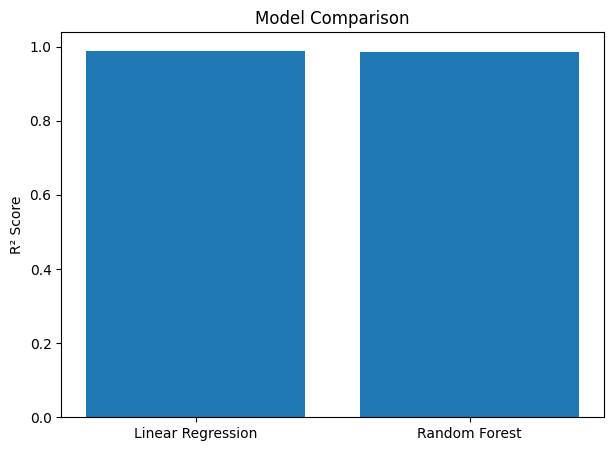

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Model Comparison")

plt.ylabel("R² Score")

plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Best Model Selection

In [12]:
if rf_r2 > lr_r2:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = lr_model
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [13]:
with open(
    "../model/model.pkl",
    "wb"
) as file:

    pickle.dump(
        best_model,
        file
    )

print("Model Saved Successfully!")

Model Saved Successfully!


## Model Evaluation Summary

Two machine learning models were evaluated:

1. Linear Regression
2. Random Forest Regressor

Linear Regression achieved the highest R² Score of 0.988983 and was selected as the final model.

The results indicate that the relationship between features and target variable is largely linear.

In [14]:
import os

os.path.exists("../model/model.pkl")

True